# 03 — YouBike Feature Engineering

This notebook builds time-series features from validated station snapshots while preventing future information from entering predictors.

> Current history contains only two snapshots. The notebook demonstrates and validates the feature pipeline; it does not claim that the data is ready for model training.

## 1. Load cleaned snapshots

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

from src.data_pipeline import (
    add_change_features,
    clean_snapshots,
    discover_snapshot_files,
    load_snapshots,
)
from src.features import build_feature_coverage, build_features

snapshot_files = discover_snapshot_files(project_root / "data" / "raw")
raw_data = load_snapshots(snapshot_files)
clean_data = add_change_features(clean_snapshots(raw_data))

print(f"Snapshots: {clean_data['snapshot_time'].nunique()}")
print(f"Stations: {clean_data['station_id'].nunique():,}")
print(f"Rows: {len(clean_data):,}")

Snapshots: 2
Stations: 1,790
Rows: 3,580


## 2. Build approved features and targets

Predictors use the current timestamp or past observations only. Future availability columns are labels and must never be passed to a model as predictors.

In [2]:
feature_data = build_features(clean_data)

selected_columns = [
    "snapshot_time",
    "station_id",
    "hour",
    "day_of_week",
    "is_weekend",
    "is_rush_hour",
    "available_bikes_lag_15m",
    "available_bikes_mean_past_30m",
    "target_available_bikes_30m",
]
feature_data[selected_columns].head()

,snapshot_time,station_id,hour,day_of_week,is_weekend,is_rush_hour,available_bikes_lag_15m,available_bikes_mean_past_30m,target_available_bikes_30m
0,2026-08-20 19:41:52+08:00,500101001,19,3,False,True,NaN,NaN,NaN
1,2026-08-20 19:56:52+08:00,500101001,19,3,False,True,24.0,24.0,NaN
2,2026-08-20 19:41:52+08:00,500101002,19,3,False,True,NaN,NaN,NaN
3,2026-08-20 19:56:52+08:00,500101002,19,3,False,True,19.0,19.0,NaN
4,2026-08-20 19:41:52+08:00,500101003,19,3,False,True,NaN,NaN,NaN


## 3. Measure real feature coverage

In [3]:
coverage = build_feature_coverage(feature_data)
coverage

,column,role,non_null_rows,usable_rows,coverage_percent
0,hour,predictor,3580,3580,100.00
1,day_of_week,predictor,3580,3580,100.00
2,month,predictor,3580,3580,100.00
3,is_weekend,predictor,3580,3580,100.00
4,is_rush_hour,predictor,3580,3580,100.00
5,hour_sin,predictor,3580,3580,100.00
6,hour_cos,predictor,3580,3580,100.00
7,day_of_week_sin,predictor,3580,3580,100.00
8,day_of_week_cos,predictor,3580,3580,100.00
9,available_bikes_lag_15m,predictor,1761,1761,49.19


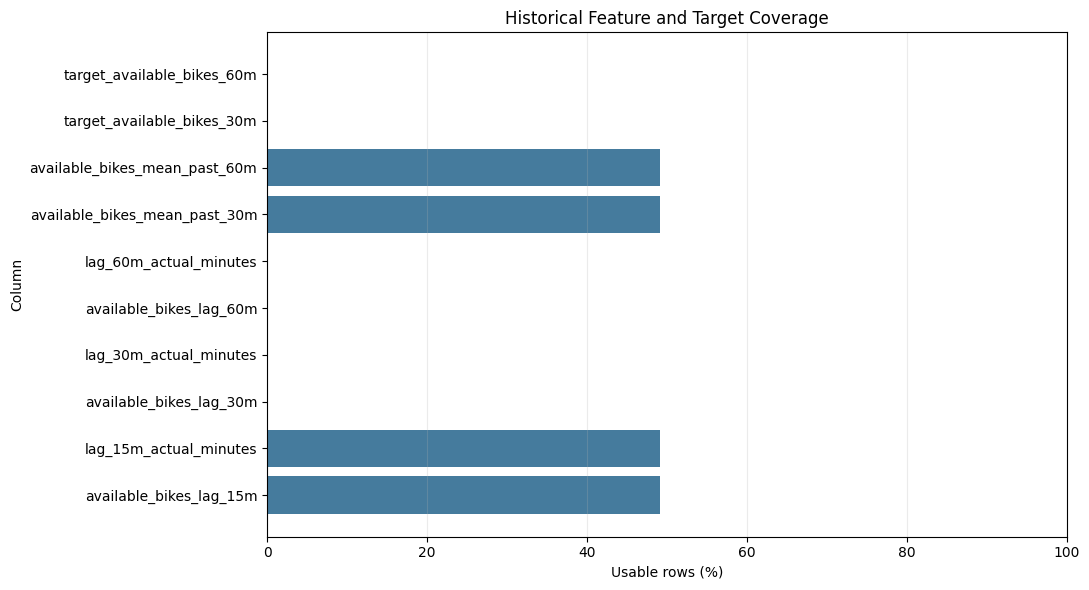

In [4]:
history_columns = coverage[
    coverage["column"].str.contains("lag_|mean_past_|target_available")
].copy()

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(history_columns["column"], history_columns["coverage_percent"], color="#457B9D")
ax.set_title("Historical Feature and Target Coverage")
ax.set_xlabel("Usable rows (%)")
ax.set_ylabel("Column")
ax.set_xlim(0, 100)
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## Interpretation

- Calendar features are available for every row.
- The second snapshot can use the first snapshot as a 15-minute lag for active stations.
- There is not yet enough elapsed history for 30/60-minute lags or future targets.
- Lag matching searches backward only, and rolling windows exclude the current observation.
- Model training must wait until real 30/60-minute targets cover a meaningful multi-day period.